In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r'C:\Users\riyas\OneDrive\Desktop\Credit_Risk_project\data\train.csv')
print("Loaded:", df.shape) 

Loaded: (9000, 122)


In [2]:
# Select features
features = [
    'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
    'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE', 
    'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
    'REGION_POPULATION_RELATIVE', 'CNT_CHILDREN'
]

df_model = df[features + ['default']].copy()

# Fix DAYS_EMPLOYED anomaly
df_model['DAYS_EMPLOYED'] = df_model['DAYS_EMPLOYED'].replace(365243, np.nan)

# Encode categorical columns
cat_cols = df_model.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = df_model[col].fillna('Unknown')
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Fill numeric nulls with median
num_cols = df_model.select_dtypes(include=np.number).columns
df_model[num_cols] = df_model[num_cols].fillna(df_model[num_cols].median())

print("Shape after preprocessing:", df_model.shape)
print("Nulls remaining:", df_model.isnull().sum().sum())


Shape after preprocessing: (9000, 16)
Nulls remaining: 0


In [3]:
# Split into features and target
X = df_model.drop('default', axis=1)
y = df_model['default']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Default rate in train: {y_train.mean():.2%}")

# Apply SMOTE to handle class imbalance
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE:")
print(pd.Series(y_train_sm).value_counts())

Training set: (7200, 15)
Test set: (1800, 15)
Default rate in train: 7.64%

After SMOTE:
default
0    6650
1    6650
Name: count, dtype: int64


In [4]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_sm)

# Evaluate
lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_auc = roc_auc_score(y_test, lr_probs)
print(f"Logistic Regression AUC: {lr_auc:.4f}")

Logistic Regression AUC: 0.7056


In [5]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, max_depth=10, 
                             random_state=42, n_jobs=-1)
rf.fit(X_train_sm, y_train_sm)

# Evaluate
rf_probs = rf.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_probs)
print(f"Random Forest AUC: {rf_auc:.4f}")

Random Forest AUC: 0.6875


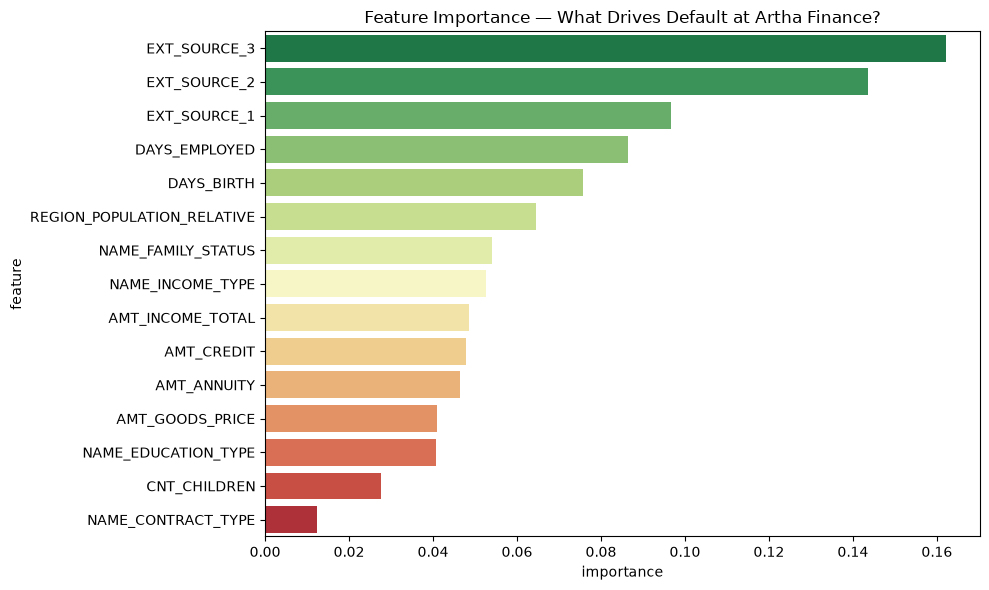

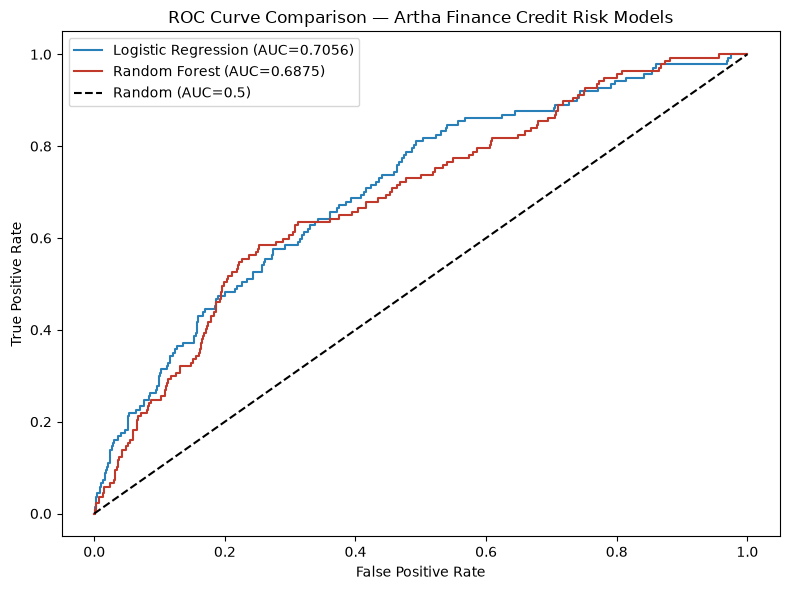

In [6]:
# Feature importance chart
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='importance', y='feature', data=feat_imp, palette='RdYlGn_r')
plt.title('Feature Importance — What Drives Default at Artha Finance?')
plt.tight_layout()
plt.savefig(r'C:\Users\riyas\OneDrive\Desktop\Credit_Risk_project\Visuals\07_feature_importance.png', dpi=150)
plt.show()

# ROC curve comparison
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, color='#2980b9', label=f'Logistic Regression (AUC={lr_auc:.4f})')
plt.plot(fpr_rf, tpr_rf, color='#c0392b', label=f'Random Forest (AUC={rf_auc:.4f})')
plt.plot([0,1], [0,1], 'k--', label='Random (AUC=0.5)')
plt.title('ROC Curve Comparison — Artha Finance Credit Risk Models')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\riyas\OneDrive\Desktop\Credit_Risk_project\Visuals\10_roc_curve.png', dpi=150)
plt.show()

Optimal threshold: 0.79
Approval rate at optimal threshold: 6.56%
Minimum total cost: ₹10,144,000


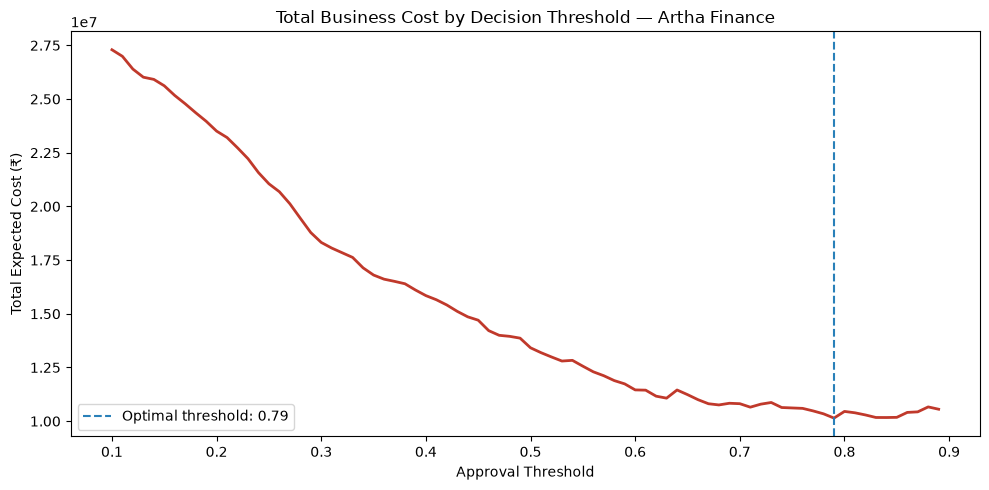

In [7]:
# Cost matrix — finding optimal business threshold
COST_FN = 80000   # Approving a defaulter — loan loss
COST_FP = 18000   # Rejecting a good borrower — lost interest

thresholds = np.arange(0.1, 0.9, 0.01)
total_costs = []
approval_rates = []

for thresh in thresholds:
    preds = (lr_probs >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    total_cost = (fn * COST_FN) + (fp * COST_FP)
    total_costs.append(total_cost)
    approval_rates.append((tp + fp) / len(y_test))

optimal_idx = np.argmin(total_costs)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal threshold: {optimal_threshold:.2f}")
print(f"Approval rate at optimal threshold: {approval_rates[optimal_idx]:.2%}")
print(f"Minimum total cost: ₹{min(total_costs):,.0f}")

# Plot
plt.figure(figsize=(10,5))
plt.plot(thresholds, total_costs, color='#c0392b', linewidth=2)
plt.axvline(x=optimal_threshold, color='#2980b9', 
            linestyle='--', label=f'Optimal threshold: {optimal_threshold:.2f}')
plt.title('Total Business Cost by Decision Threshold — Artha Finance')
plt.xlabel('Approval Threshold')
plt.ylabel('Total Expected Cost (₹)')
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\riyas\OneDrive\Desktop\Credit_Risk_project\Visuals\08_cost_threshold.png', dpi=150)
plt.show()